In [1]:
model_slug = "Phi-3-mini-128k-instruct"

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load .pt file
data = torch.load(f"elicit-beliefs-{model_slug}.pt", weights_only=False)
logits = data["logits"]
top_other_logit = data["top_other_logit"]
top_other_id = data["top_other_id"]
top_other_token = data["top_other_token"]

In [3]:
from mycode import WORDS, YES, NO, TRUE, FALSE, PROMPT_TEMPLATES, logits_to_affirm_prob, present_results

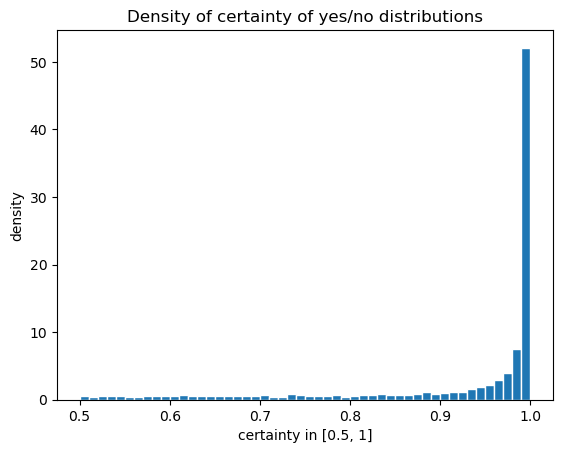

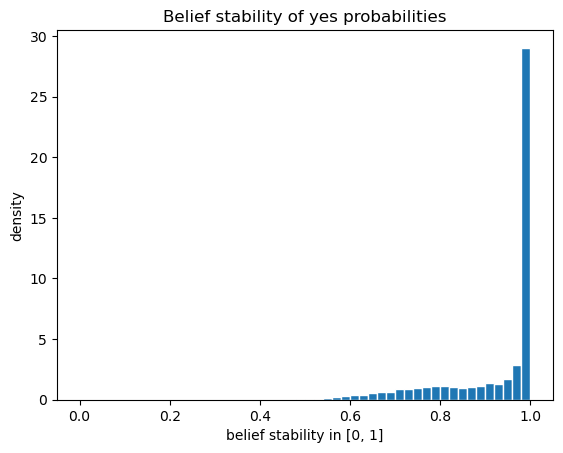

In [4]:
p_affirm = logits_to_affirm_prob(logits, prompts=[0, 1, 2, 3])
present_results(p_affirm)

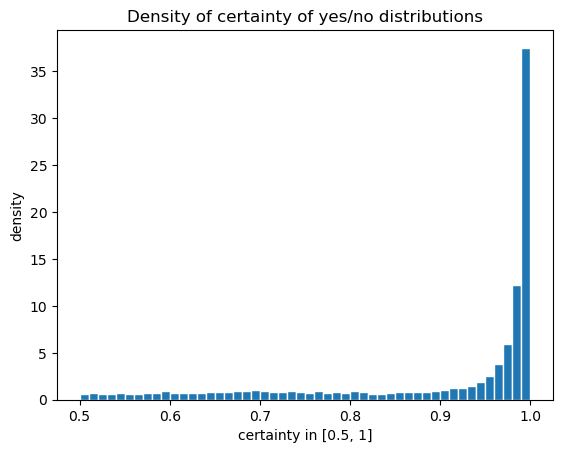

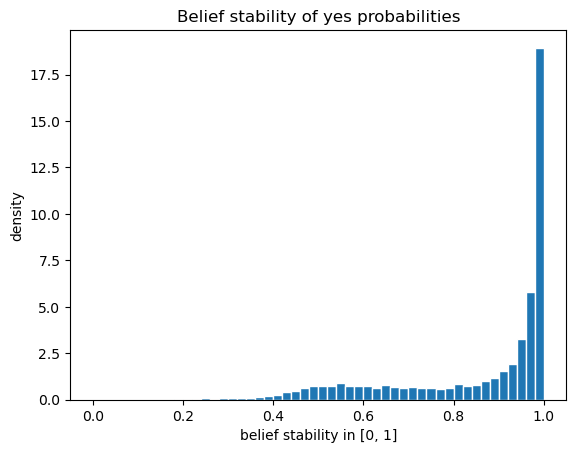

In [5]:
p_affirm = logits_to_affirm_prob(logits, prompts=[4, 5, 6, 7])
present_results(p_affirm)

In [6]:
all_logits = torch.hstack((logits, top_other_logit[:,None]))
all_probs = all_logits.softmax(axis=1)

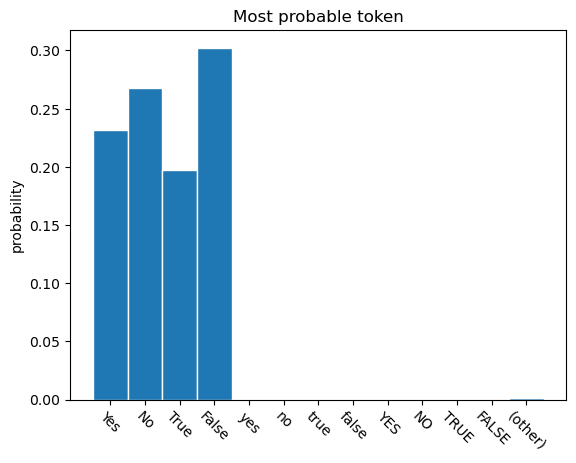

In [7]:
plt.title("Most probable token")
plt.hist(all_probs.argmax(dim=1), bins=np.arange(len(WORDS)+2) - 0.5, edgecolor='white', density=True)
plt.xticks(np.arange(len(WORDS)+1), WORDS + ["(other)"], rotation=-45)
plt.ylabel('probability')
plt.show()

In [8]:
# Most probable other token
from collections import Counter
Counter(top_other_token)

Counter({'The': 44934,
         '**': 30652,
         'I': 11804,
         'Answer': 2528,
         'Correct': 2490,
         'Without': 1255,
         'B': 391,
         'San': 213,
         'K': 210,
         'Both': 176,
         'T': 165,
         'John': 165,
         'M': 163,
         'Z': 160,
         'C': 151,
         'H': 150,
         'Charles': 148,
         'S': 141,
         'Al': 137,
         'Ch': 129,
         'N': 128,
         'Sh': 128,
         'If': 126,
         'O': 126,
         'A': 121,
         'Y': 121,
         'G': 110,
         'L': 107,
         'George': 107,
         'Joseph': 99,
         'D': 96,
         'Port': 96,
         'X': 92,
         'China': 90,
         'P': 90,
         'Mar': 85,
         'J': 83,
         'Br': 83,
         'R': 82,
         'Th': 81,
         'Mal': 76,
         'James': 75,
         'Hans': 73,
         'West': 70,
         'While': 69,
         'F': 69,
         'Santa': 68,
         'Saint': 65,
         'V': 6

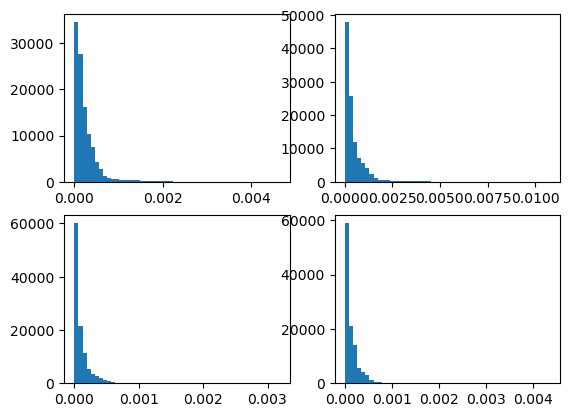

In [9]:
# histogram of yes/Yes, no/No, true/True, false/False
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.hist(all_probs[:, i+4] / all_probs[:, i], bins=50);
plt.show()

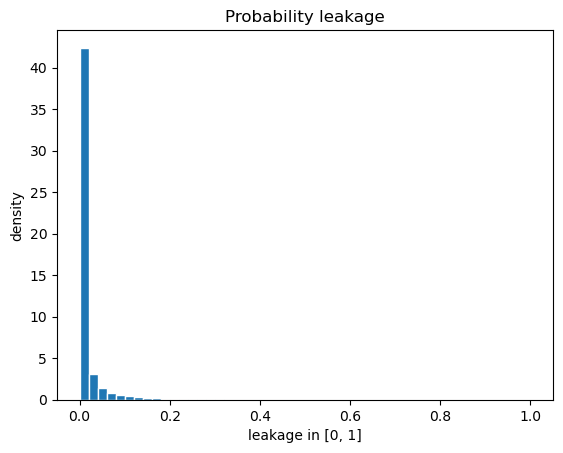

In [10]:
leakage = all_probs[:,-1]

plt.figure()
plt.title("Probability leakage")
plt.hist(leakage, bins=np.linspace(0, 1, 51), density=True, edgecolor="white")
plt.xlabel("leakage in [0, 1]")
plt.ylabel("density")

plt.show()

In [11]:
# Most probable token is other, what is it?
other_wins = (all_probs.argmax(axis=1) == len(WORDS)).argwhere()
Counter([top_other_token[i] for i in other_wins])

Counter({'The': 63,
         'I': 25,
         'Without': 3,
         'Gib': 3,
         'X': 2,
         'Hu': 2,
         'Y': 2,
         'Jos': 2,
         'Ji': 2,
         'Victoria': 2,
         'Ern': 2,
         'T': 1,
         'Com': 1,
         'As': 1,
         'Kim': 1,
         'Hi': 1,
         'Kam': 1,
         'Eug': 1,
         'Ty': 1,
         'Lima': 1,
         'Freder': 1,
         'J': 1,
         'Or': 1,
         'Regin': 1,
         'Mor': 1,
         'Alo': 1,
         'M': 1,
         'Mar': 1,
         'H': 1,
         'Balt': 1,
         'Cleveland': 1,
         'Jam': 1,
         'Ros': 1,
         'Tan': 1,
         'Elizabeth': 1,
         'So': 1,
         'Z': 1,
         'Sof': 1,
         'Ralph': 1,
         'Rudolf': 1})